# Noise-Aware ANNNI Phase Diagnostics
## Low-CNOT preparation, error mitigation, and their limits
**Team hamster — Shupei Zhang, Yangxin Zhou, Michael Li, Kathy Chen.** Q-SITE 2026, Scientific Track.

A self-contained research submission. The strongest result is a resource-aware improvement in observables, accompanied by explicit limits on phase-feature reconstruction. The evaluated outputs are observable errors, resource costs and finite-size phase features.

**Execution categories:** `archived_results` are the frozen scientific experiments; `recomputed_from_saved_data` rebuilds their figures/statistics; `fresh_light_validation` reruns one explicit circuit and saved-count reconstruction. Run All never optimizes a grid or runs DMRG.

The main 420-point maps, 96-coordinate confirmation, 48 low-field confirmation subset, 45-point resource comparison and 102 window coordinates have different denominators. The 45 and 102 sets overlap; their union is 110, not 147.

In [1]:
from pathlib import Path
import sys, json, numpy as np
ROOT = Path.cwd().resolve()
assert (ROOT / "scripts/release.py").is_file(), "Run with the submission root as working directory"
sys.path.insert(0, str(ROOT / "scripts"))
import release
from IPython.display import display, Image, Markdown
OUT = ROOT / "build/notebook"
OUT.mkdir(parents=True, exist_ok=True)
print(release.env())
print("Inputs: repository-relative files")


{'python': '3.12.14', 'python_build': '3.12.14 (main, Aug 25 2026, 13:50:33) [Clang 22.1.3 ]', 'numpy': '2.3.5', 'scipy': '1.17.0', 'platform': 'macOS-26.6.2-arm64-arm-64bit', 'machine': 'arm64', 'bit_generator': 'PCG64'}
Inputs: repository-relative files


## Model, observables and noise
$$H=-\sum_iZ_iZ_{i+1}+\kappa\sum_iZ_iZ_{i+2}-h\sum_iX_i.$$
Small circuits use N=8 or 12, PBC, wire 0 = most-significant bit. Large MPS results use OBC and are not transplanted as N8 labels.
$$C(r)=N^{-1}\sum_i\langle Z_iZ_{i+r}\rangle,\quad M_x=N^{-1}\sum_i\langle X_i\rangle,\quad m_q^2=N^{-2}\sum_{ij}e^{iq(i-j)}\langle Z_iZ_j\rangle.$$
All discrete q and distances are kept. Self correlations give the 1/N background; an ideal period-four antiphase has $m_{\pi/2}^2=1/2$. h=0 classical mixtures are separate from the positive-h pure-state protocol. No interpolation of missing h=0 fidelities.

After **each literal CNOT**, only its target receives $D_p(\rho)=(1-p)\rho+\frac p3(X\rho X+Y\rho Y+Z\rho Z)$, p=0,.01,.05. Reference preparation, decoding and folding count. The connection assumption is direct NN/NNN gates, with recorded extra support/routing in literal tables, not the other track's 20-qubit hardware graph.

Source implementations: `annni/model.py`, `circuits.py`, `upgrade_gates.py`, `upgrade_adapt.py`, `stage6_candidates.py`, `upgrade_mitigation.py`. PennyLane 0.44.1 provides the original HVA and independent density crosscheck; the explicit NumPy backend executes the same archived gates for efficient repeated simulations.

## Preparation and independent reference
B0 is a six-layer Hamiltonian variational circuit (192 CNOT). Each layer applies NN ZZ rotations, NNN ZZ rotations, then RX: angle 2 theta means exp(-i theta P). B3 grows Pauli rotations from multiple references, optimizing energy, then selecting by the frozen energy/resource rule. It uses no ED StatePrep. The literal gate table and selected parameters for every B3 map point are bundled in `data/core/b3_map_circuits.json`.

A state passes only when delta e <= .001 per spin, max C/SF/Mx errors <= .02, and squared ED fidelity >= .99. Optimizer success, observable pass and state pass are separate.

R0 is supported region-interior evidence; RN is a same-size ED feature, allowing disagreement; Rlarge is larger-size evidence with boundary/size qualifications. Frozen D3 (PCA + clustered reference resemblance, with degraded-state control) is displayed consistently because it is the established baseline, not because it is a newly selected confirmation winner. D3-on-ED is an ideal diagnostic output, not independent physical truth.

[
  {
    "p": 0,
    "n": 420,
    "B0_median_CNOT": 192.0,
    "B3_median_CNOT": 96.0,
    "B0_joint_pass": 407,
    "B3_joint_pass": 385,
    "B0_mean_max_C_error": 0.0019264822058457755,
    "B3_mean_max_C_error": 0.004703970688472746,
    "B3_better": 17
  },
  {
    "p": 0.01,
    "n": 420,
    "B0_median_CNOT": 192.0,
    "B3_median_CNOT": 96.0,
    "B0_joint_pass": 407,
    "B3_joint_pass": 385,
    "B0_mean_max_C_error": 0.2637546695248888,
    "B3_mean_max_C_error": 0.1431838708115352,
    "B3_better": 402
  },
  {
    "p": 0.05,
    "n": 420,
    "B0_median_CNOT": 192.0,
    "B3_median_CNOT": 96.0,
    "B0_joint_pass": 407,
    "B3_joint_pass": 385,
    "B0_mean_max_C_error": 0.44536145816306466,
    "B3_mean_max_C_error": 0.36661281532549406,
    "B3_better": 418
  }
]


{'figures': ['phase_p0', 'phase_p001', 'phase_p005', 'phase_comparison', 'phase_single_raw', 'phase_single_zne_quadratic', 'reference_scope', 'resource_tradeoff', 'equal_resource', 'bias_sampling', 'window_coverage', 'six_windows', 'window_example', 'extensions', 'floating_evidence', 'dynamics', 'floating_fit_sensitivity', 'slide_phases', 'slide_reference']}


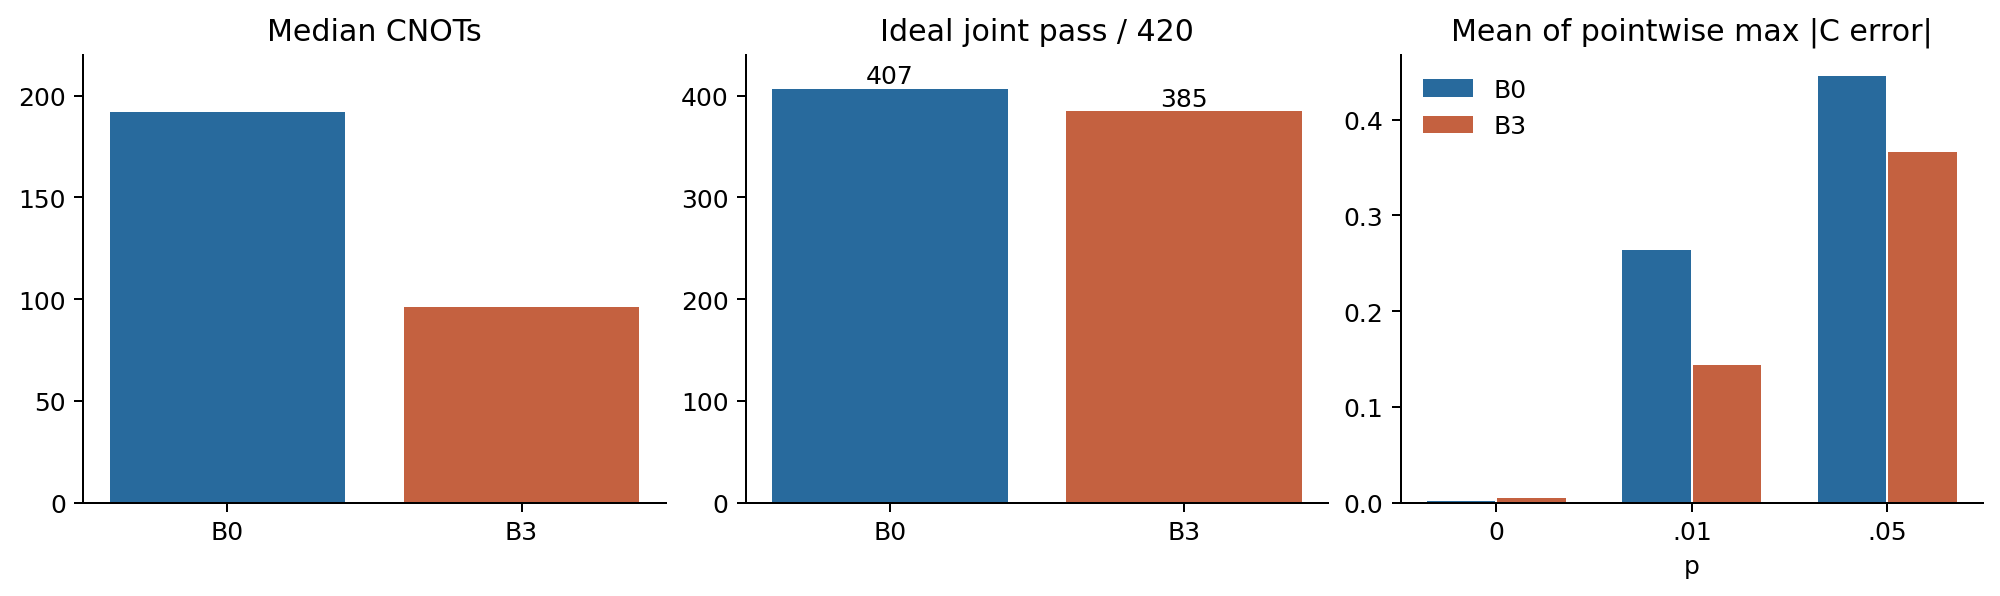

In [2]:
stats = release.statistics(OUT)  # recomputed_from_saved_data
print(json.dumps(stats["b0_b3"], indent=2))
from release_figures import draw
figure_receipt = draw(OUT, stats)  # all charts rebuilt from numeric files
print(figure_receipt)
display(Image(filename=str(OUT / "resource_tradeoff.png")))

## The required three noise maps
Exact-expectation raw B3 maps use the same grid and frozen D3. Crosses retain failed ideal preparations; they do not erase the detector output. Colors encode the frozen D3 pattern-resemblance classes. The displayed unassigned class and degraded class are separate. Branch sensitivity is separately recorded for the six windows; the main grid is not falsely marked branch-safe.

Below, ED reference, ideal circuit and noisy circuits are shown side by side. The independent reference coverage has its own panel.

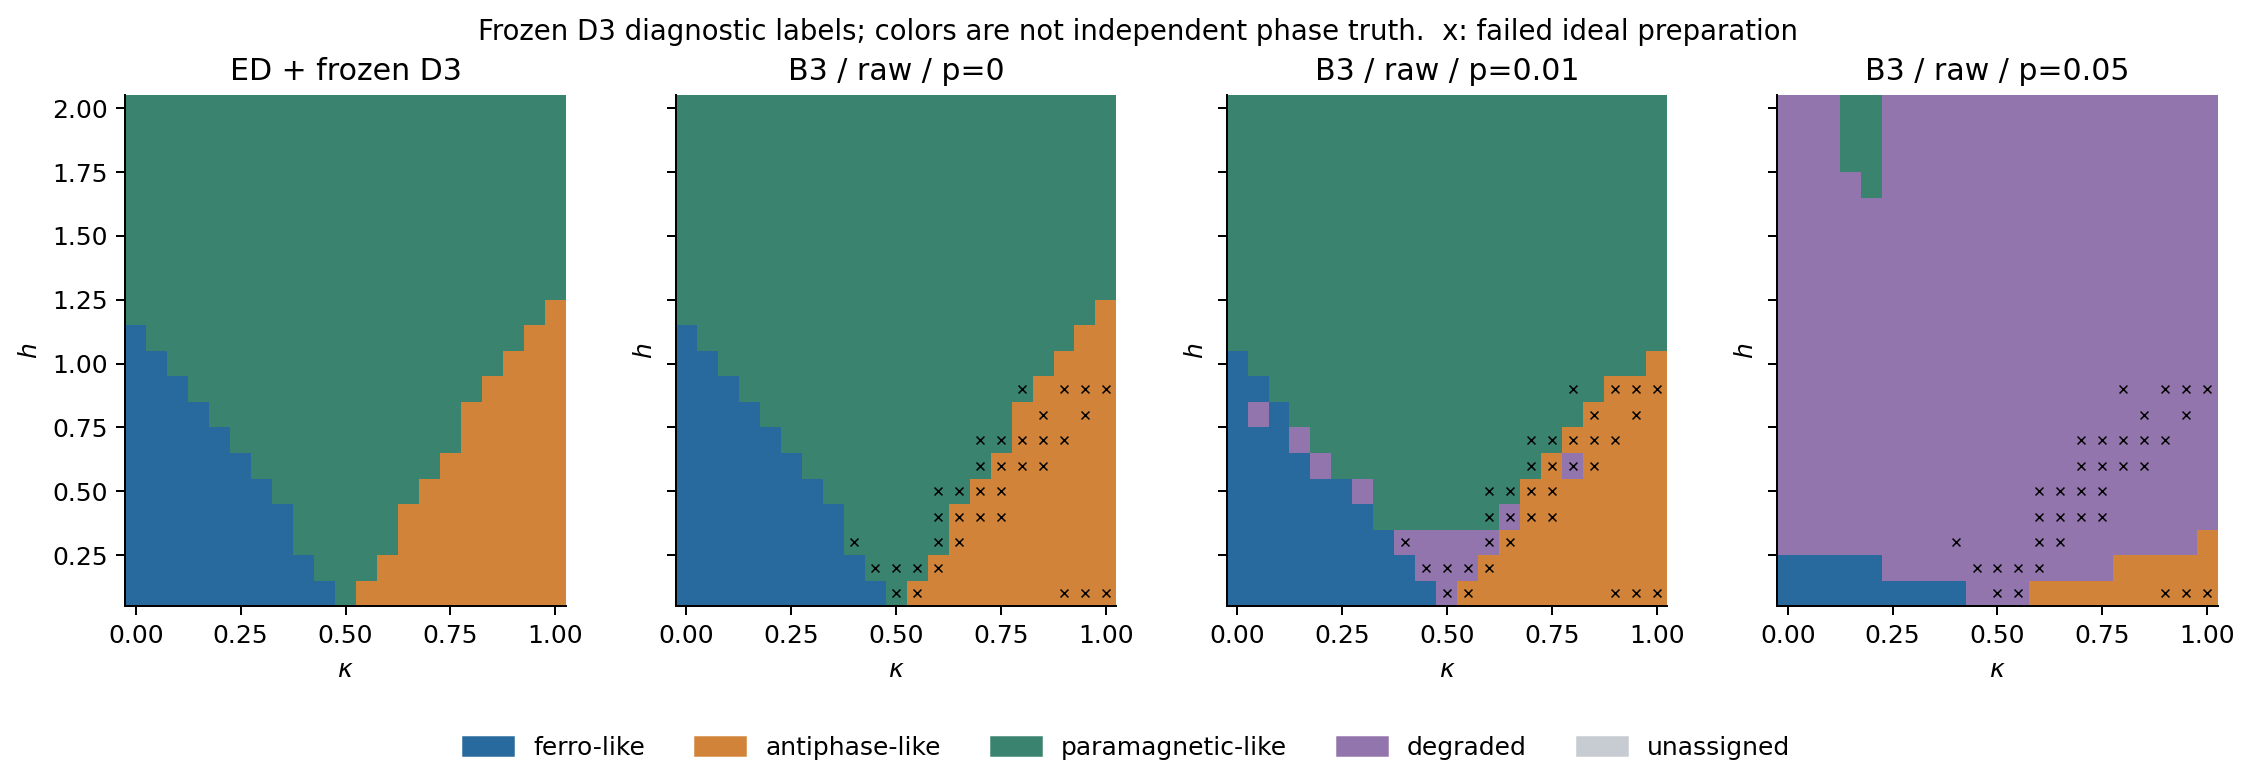

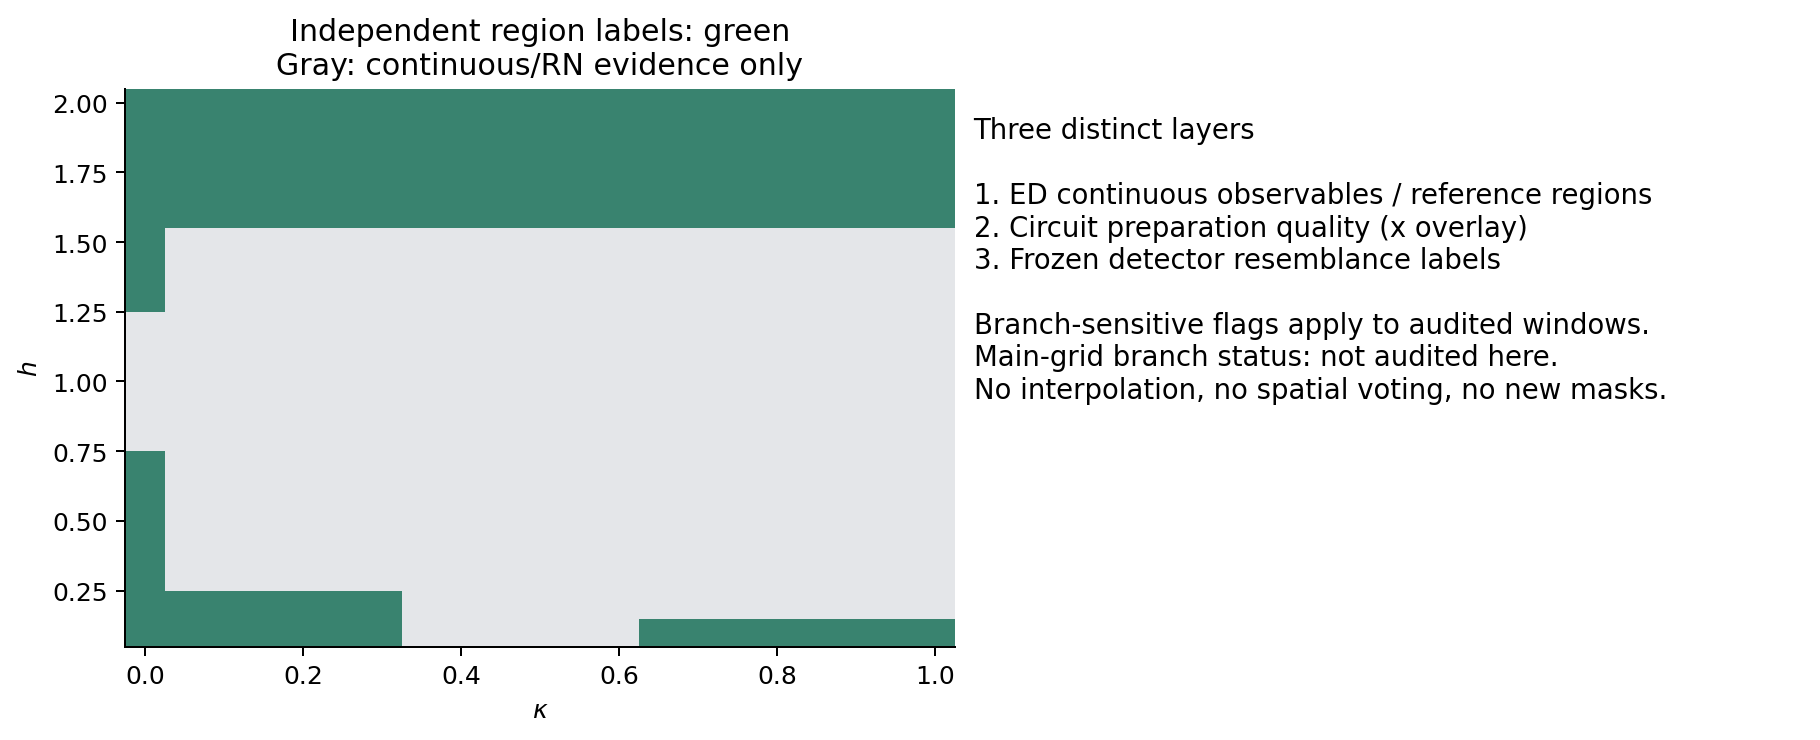

In [3]:
display(Image(filename=str(OUT / "phase_comparison.png")))
display(Image(filename=str(OUT / "reference_scope.png")))

### Finite-measurement and mitigation maps
The following maps use **one archived repeat, 100,000 total shots per point and p**. Quadratic ZNE divides that total among folds 1/3/5 and X/Z settings. These are equal-shots maps, NOT equal-CNOT-shots maps. The 45-coordinate true equal-resource comparison below is never painted over all 420 points.

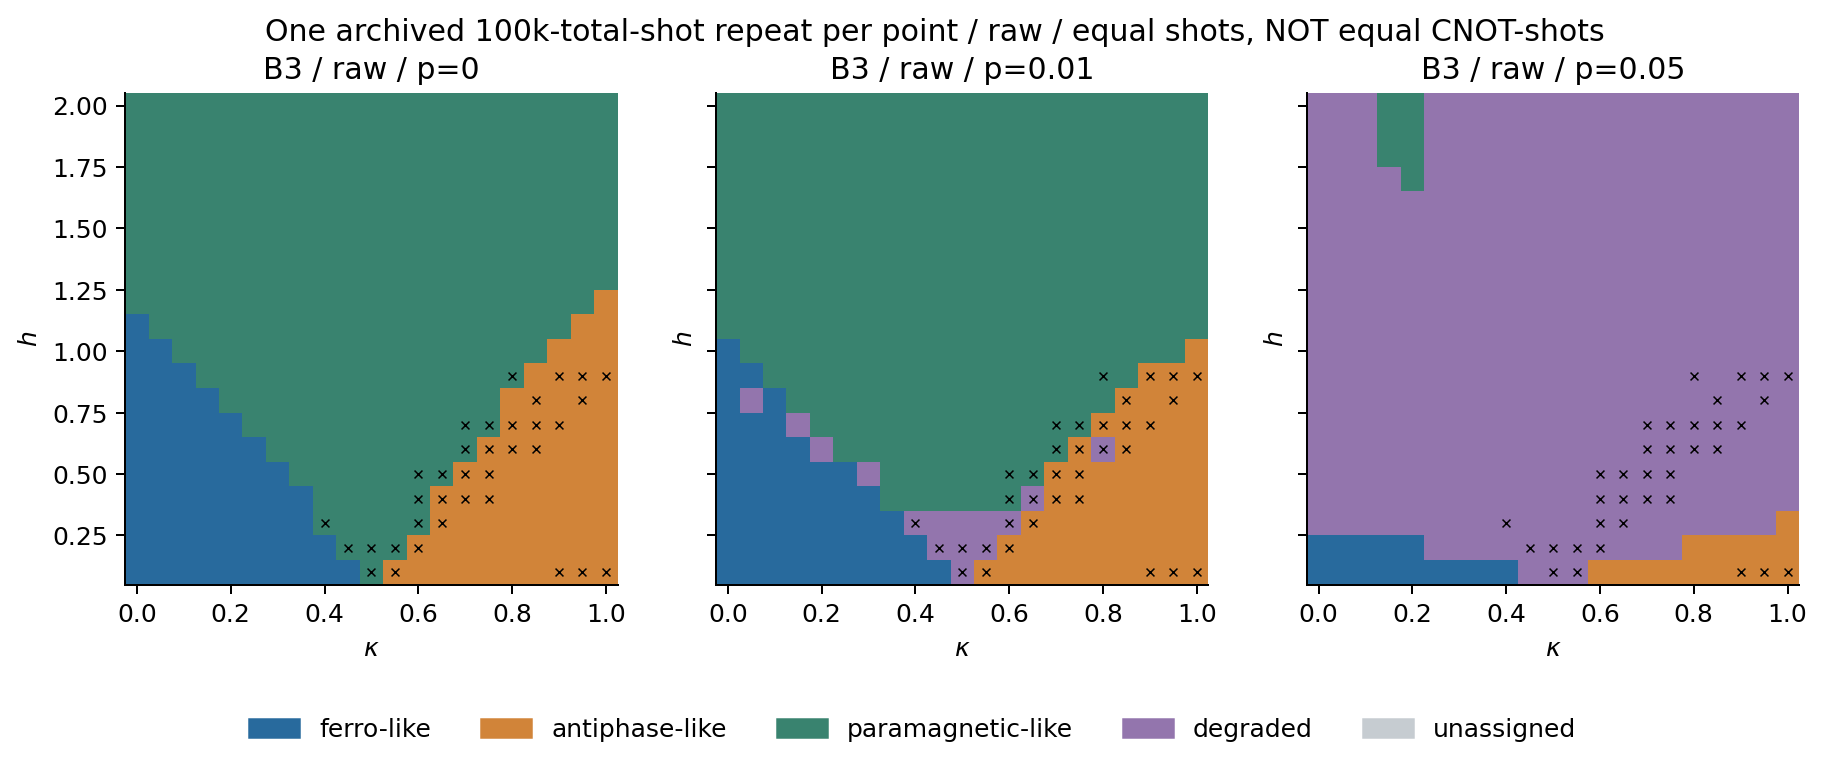

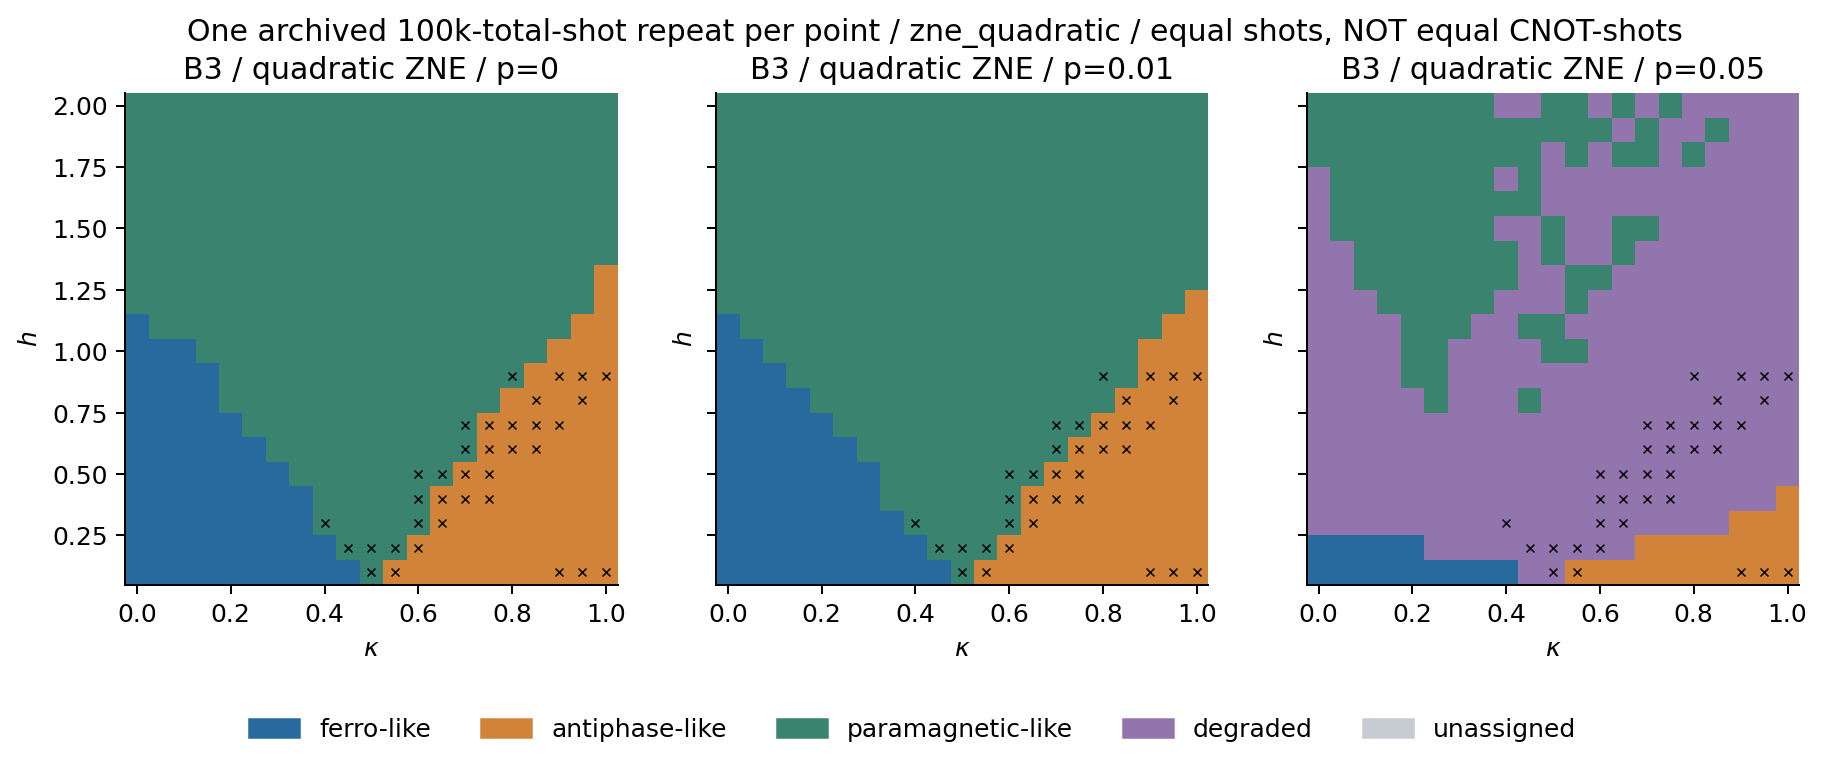

In [4]:
display(Image(filename=str(OUT / "phase_single_raw.png")))
display(Image(filename=str(OUT / "phase_single_zne_quadratic.png")))

## Equal-resource mitigation
Quadratic ZNE combines scales 1/3/5 with weights (15/8,-5/4,3/8); linear ZNE is a distinct archived baseline. Symmetry verification estimates $(\langle O\rangle+\langle OP\rangle)/(1+\langle P\rangle)$, $P=\prod_iX_i$, preserving the YY sign and covariance from shared bitstrings. SV is not a momentum projection.

The main budget is G=100,000 times the point's original CNOT count. Raw and SV use 100,000 shots; quadratic ZNE uses 33,334, split 11,112/11,111/11,111. Integer G matches exactly. The higher budget uses actual G=299,998 times CNOT, keeping the two-CNOT-shot shortfall rather than padding. G is not all computational cost; settings and single-qubit gates are retained.

The unchanged error is the mean of 17 squared component errors: eight C, eight Fourier-related SF, and Mx. The redundant weighting is acknowledged, not changed after seeing outcomes. Means across 32 repeats do not equal one 100k experiment. ED-target and own-p0-target errors remain separate.

[
  {
    "mode": "equal_gate",
    "budget": 100000,
    "p": 0,
    "method": "raw",
    "n": 45,
    "labelled": 6,
    "MSE_ED": 9.615583734423254e-05,
    "MSE_own_p0": 1.2451518360312574e-06,
    "bias_squared": 9.487207949202041e-05,
    "sampling_MSE": 1.245151836031255e-06,
    "shots": 100000.0,
    "G": 10460000.0,
    "settings": 2.0
  },
  {
    "mode": "equal_gate",
    "budget": 100000,
    "p": 0,
    "method": "sv",
    "n": 45,
    "labelled": 6,
    "MSE_ED": 0.00010363441195031421,
    "MSE_own_p0": 9.843395178313987e-06,
    "bias_squared": 9.48720794920205e-05,
    "sampling_MSE": 9.843395178314057e-06,
    "shots": 100000.0,
    "G": 10460000.0,
    "settings": 30.0
  },
  {
    "mode": "equal_gate",
    "budget": 100000,
    "p": 0,
    "method": "zne_quadratic",
    "n": 45,
    "labelled": 6,
    "MSE_ED": 0.00015727574408654202,
    "MSE_own_p0": 5.830980523149782e-05,
    "bias_squared": 9.487207949202038e-05,
    "sampling_MSE": 5.8309805231497786e-05,
    

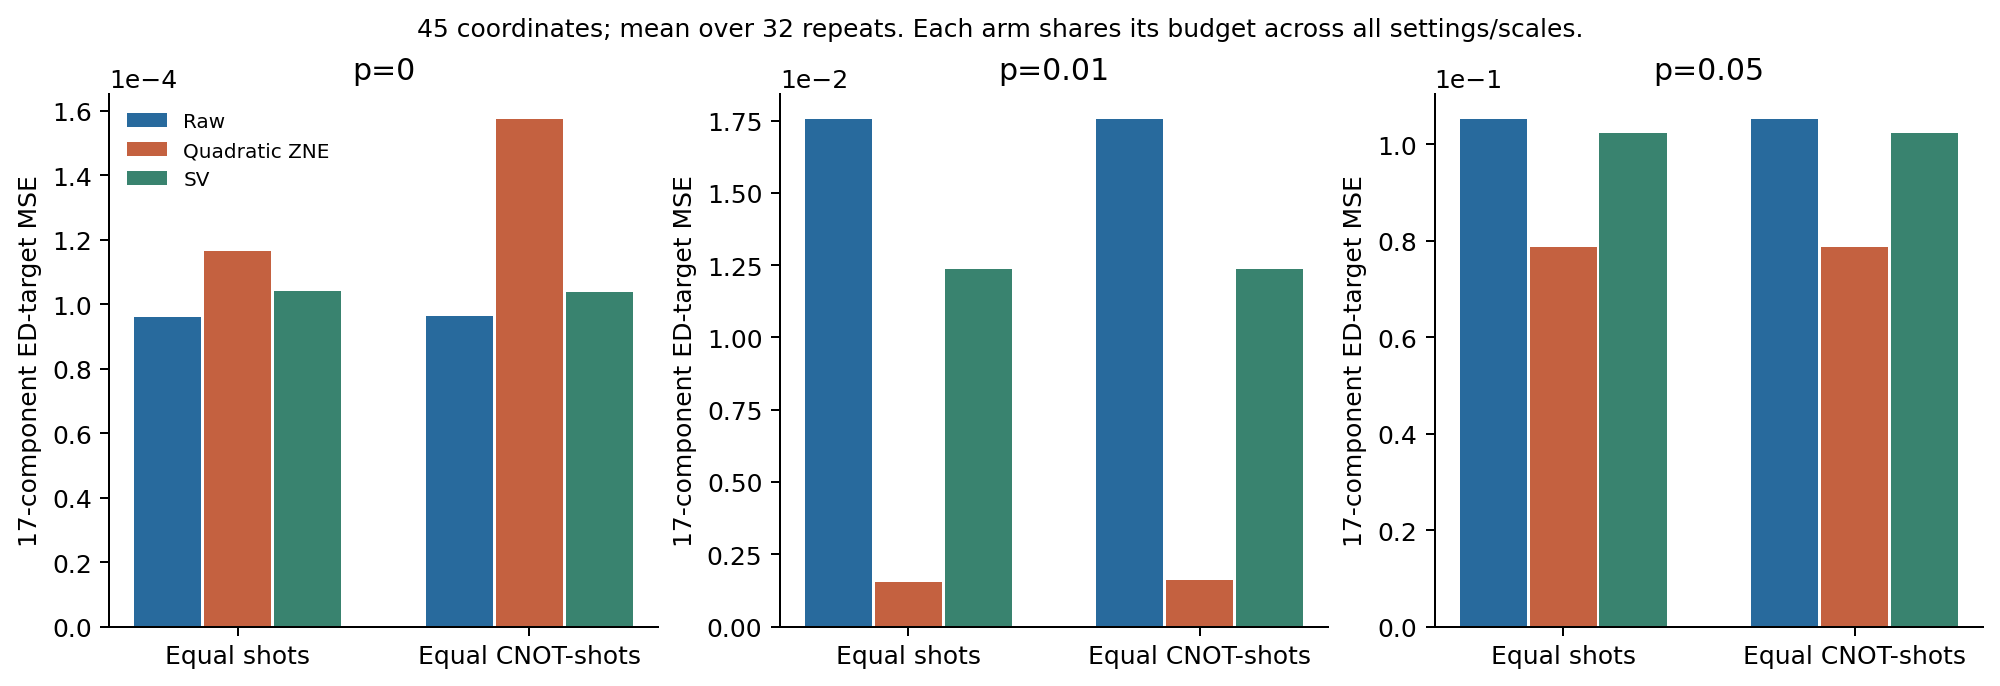

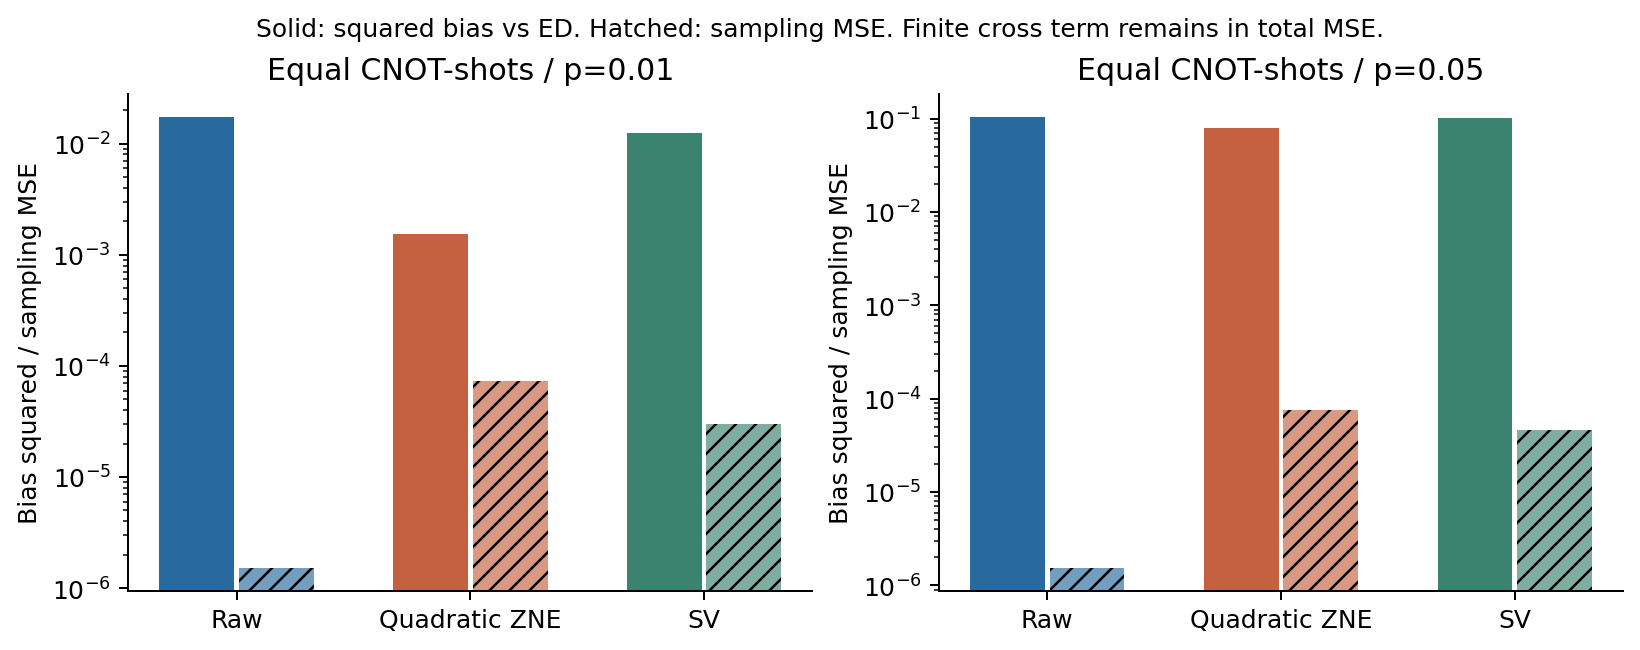

In [5]:
print(json.dumps([r for r in stats["equal_resource"] if r["mode"]=="equal_gate" and r["budget"]==100000], indent=2))
display(Image(filename=str(OUT / "equal_resource.png")))
display(Image(filename=str(OUT / "bias_sampling.png")))

ZNE improves coordinate-mean MSE for all 45 coordinates at p=.01 and .05, but worsens all 45 at p=0. This is not improvement in every random repeat, nor phase accuracy: only six resource-cohort coordinates have independent interior labels. Bias reduction and increased sampling error are both visible.

## Local response features and their limits
All six 17-point windows (kappa=0,.3,.45,.5,.55,.8) are retained. Five references are resolvable under the frozen rule; kappa=.5 fails the frozen peak-selection criterion. Matching uses the same feature, includes endpoint/multi-peak failures, and is paired with preparation and branch audits. Window-equivalent counts are averages over 32 repetitions, not numbers of established phase transitions.

The kappa=.8 example was specified before the followup and records a feature-reconstruction failure. Exact expectations isolate preparation/noise effects. Full sampled curves and empirical quantiles are included in the data; they are not thermodynamic confidence intervals.

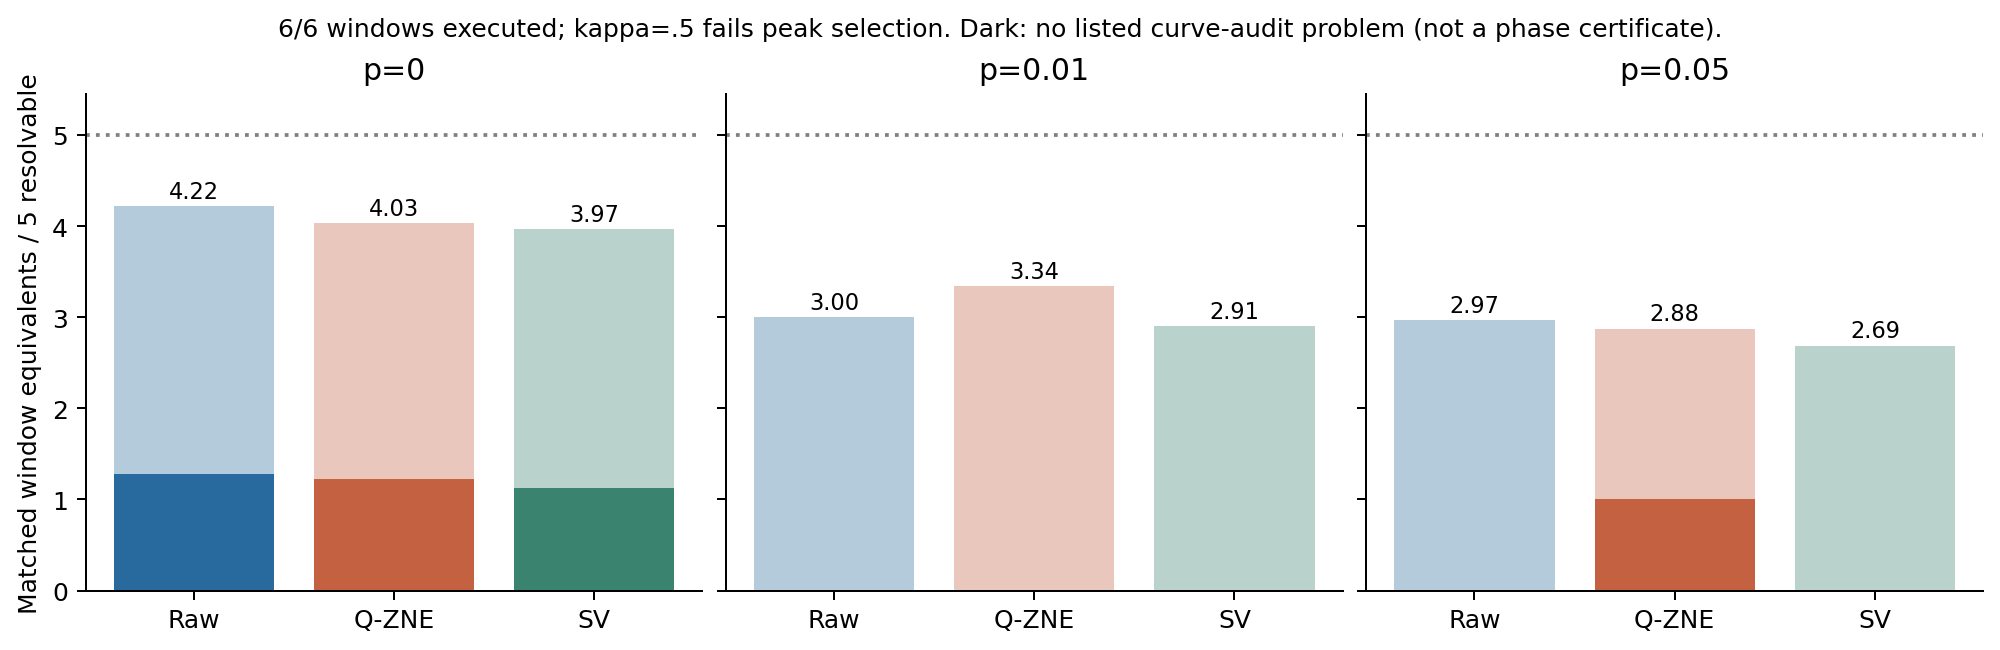

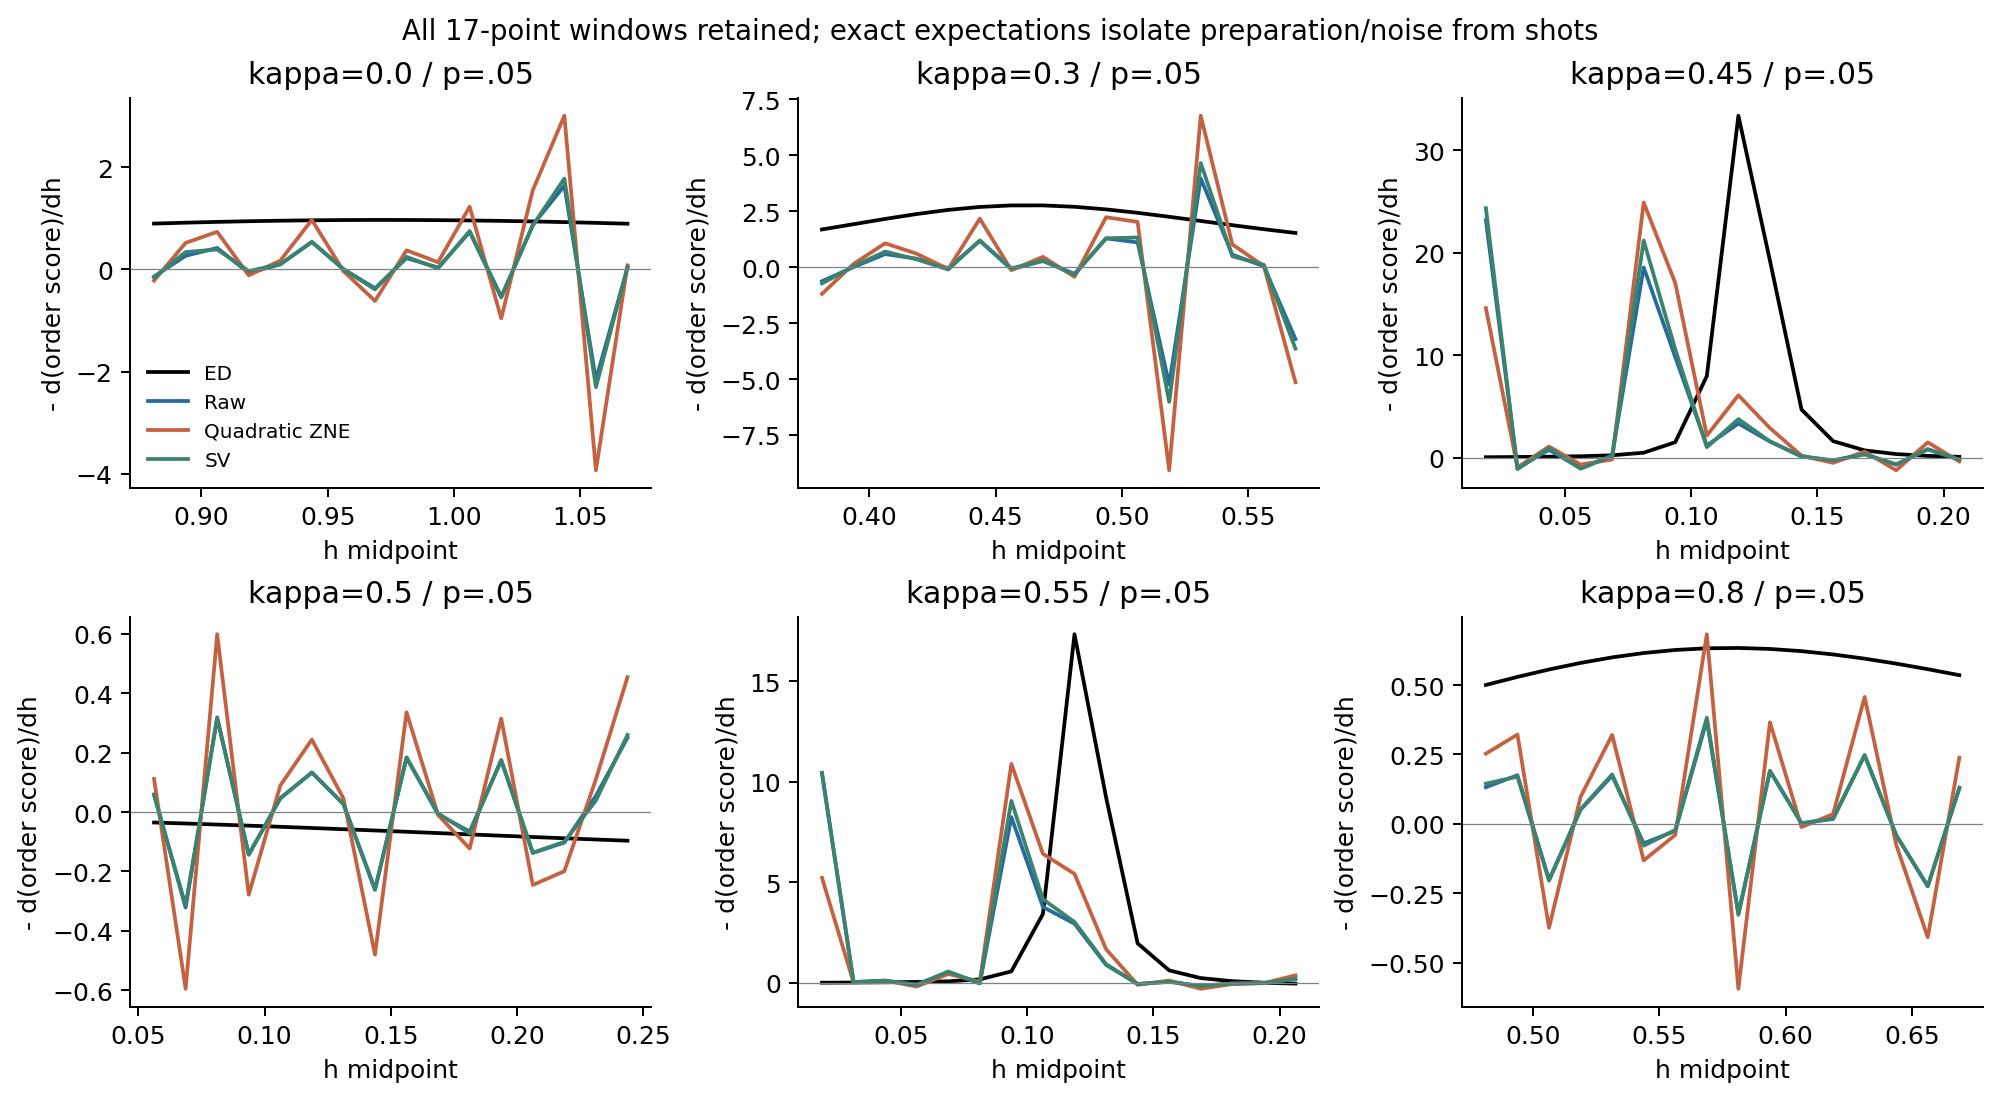

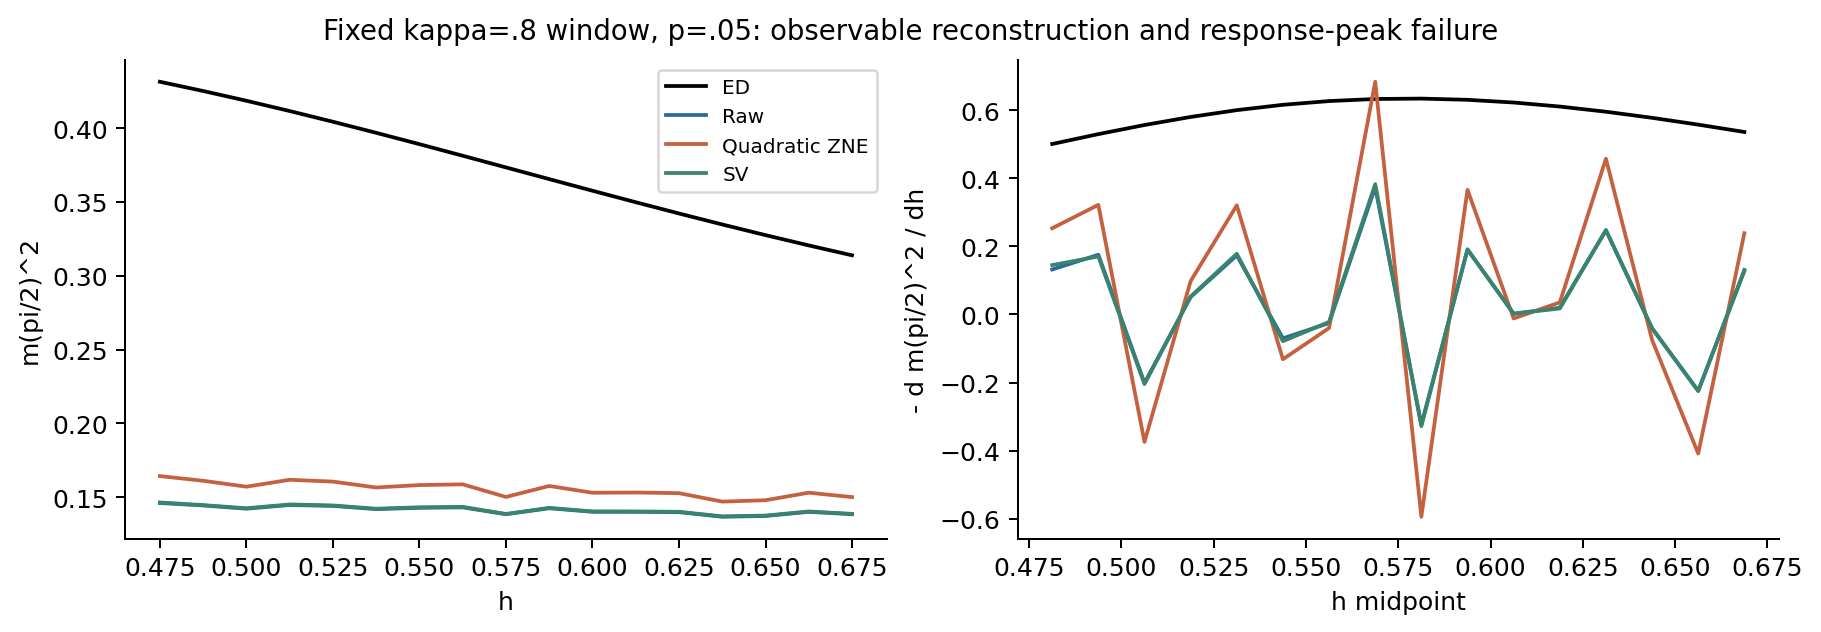

In [6]:
display(Image(filename=str(OUT / "window_coverage.png")))
display(Image(filename=str(OUT / "six_windows.png")))
display(Image(filename=str(OUT / "window_example.png")))

## Five extensions and their evidence limits
1. **N>=12:** difficult-region transfer was executed. H6 does not outperform B3 there.
2. **Multiple detectors:** frozen D1/D3 and newer D4/D5 are preserved; no universal improved detector is claimed. D2 uses full-state access and is not free under local-shot budgets.
3. **Mitigation:** raw/linear/quadratic ZNE/SV implementations and equal-resource raw/quadratic/SV tests are available. At p=.05, raw B3 D3 assigns 384/420 main-grid points to the degraded class.
4. **Dynamics:** archived product-state quench/Trotter comparisons distinguish discretization and noise; no new quench runs in this release.
5. **Floating search:** the controlled kappa=.8 OBC slice establishes antiphase/PM-side controls. h=.4/.425 belong to the screened subset. The final evidence contains zero supported floating samples and zero established transition brackets. The chi=512 timeout at .35 is a resource failure, not exclusion of a phase.

H6 is a regionally frozen union of physical/domain-wall candidates, not six-layer HVA. N8 low-field candidate availability improves at greater gate/search cost; N12 selected passes are 23/36 for B3 and 17/36 for H6.

[
  {
    "cohort": "low_field_confirmation",
    "method": "B3",
    "n": 48,
    "candidate_exists": 27,
    "joint_pass": 27,
    "observable_pass": 28,
    "median_CNOT": 32.0,
    "nfev": 678228.0
  },
  {
    "cohort": "low_field_confirmation",
    "method": "H6",
    "n": 48,
    "candidate_exists": 45,
    "joint_pass": 37,
    "observable_pass": 45,
    "median_CNOT": 127.0,
    "nfev": 5050938.0
  },
  {
    "cohort": "confirmation",
    "method": "B3",
    "n": 96,
    "candidate_exists": 67,
    "joint_pass": 66,
    "observable_pass": 68,
    "median_CNOT": 64.0,
    "nfev": 1344484.0
  },
  {
    "cohort": "confirmation",
    "method": "H6",
    "n": 96,
    "candidate_exists": 85,
    "joint_pass": 77,
    "observable_pass": 85,
    "median_CNOT": 127.0,
    "nfev": 5746986.0
  },
  {
    "cohort": "n12",
    "method": "B3",
    "n": 36,
    "candidate_exists": 24,
    "joint_pass": 23,
    "observable_pass": 24,
    "median_CNOT": 96.0,
    "nfev": 306078.0
  },
  {
   

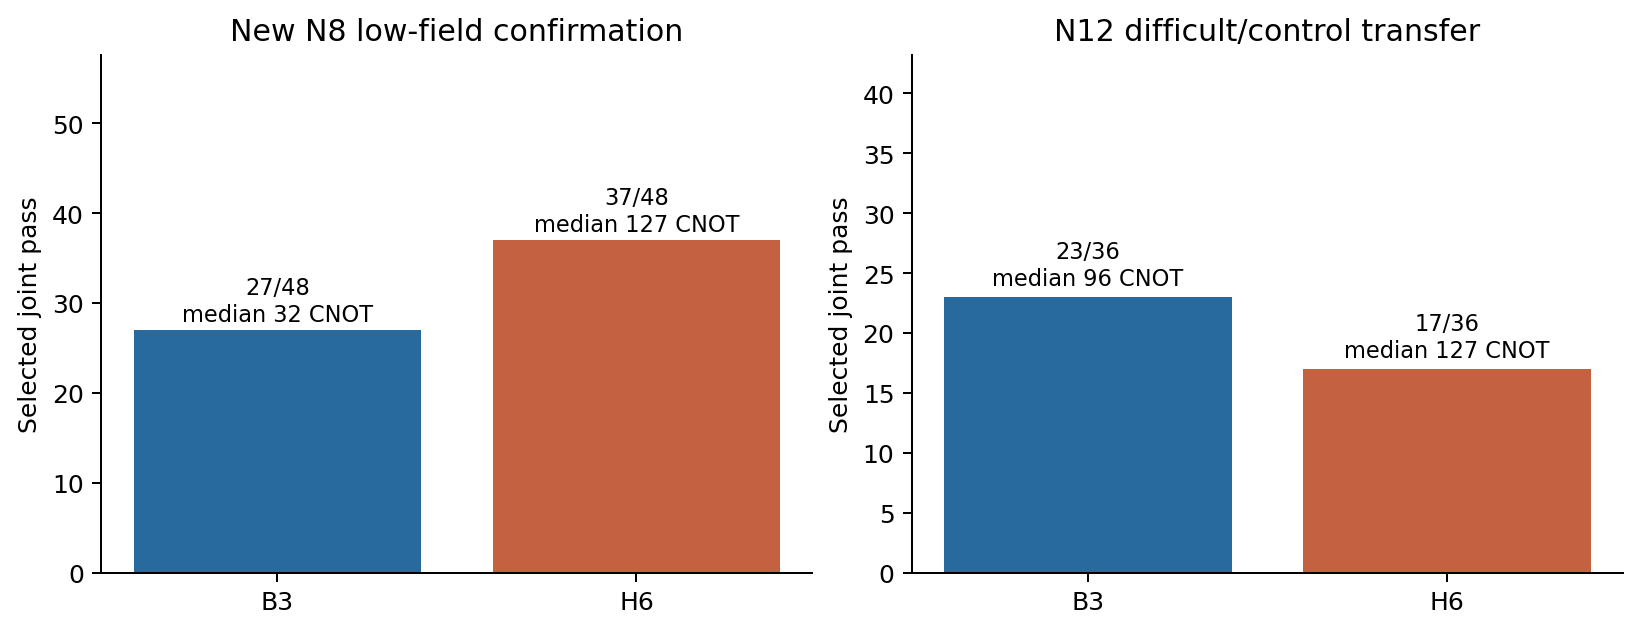

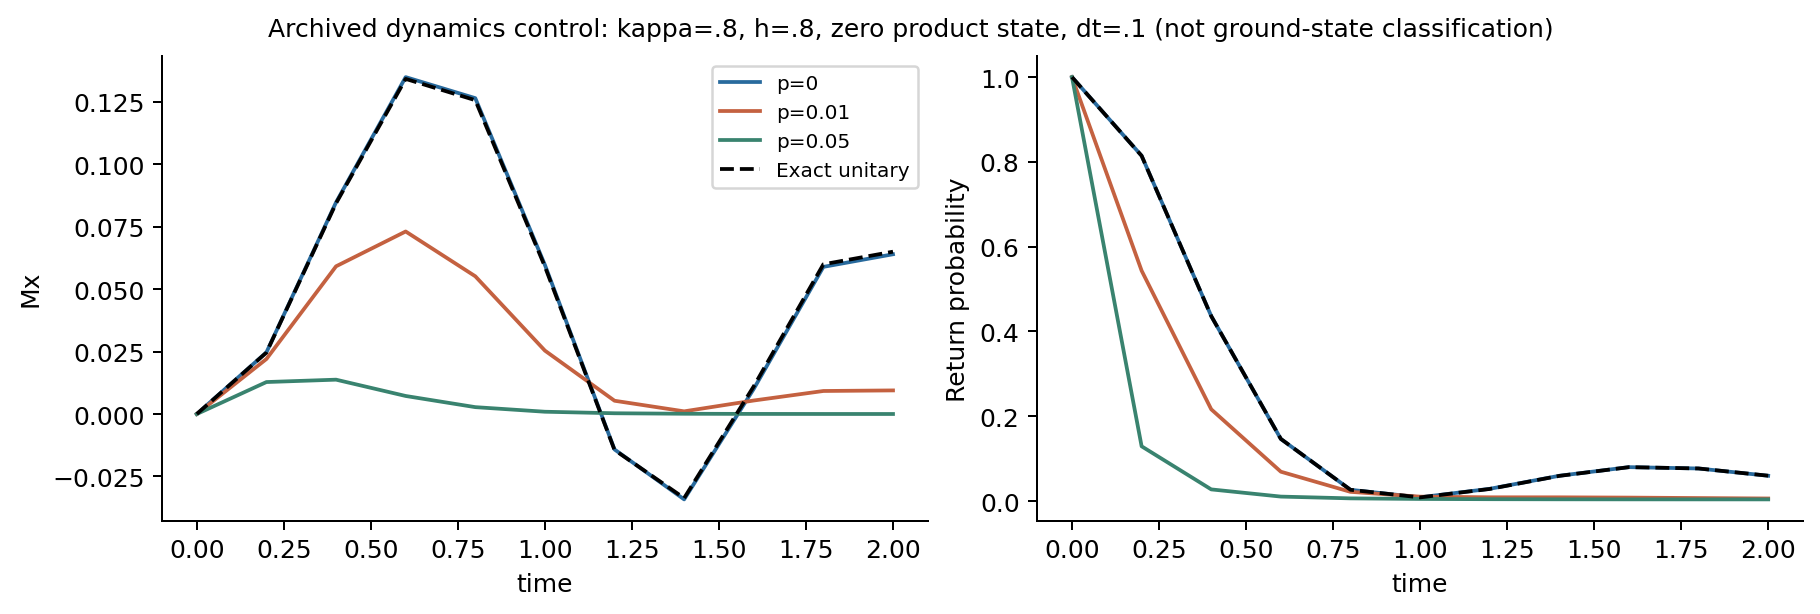

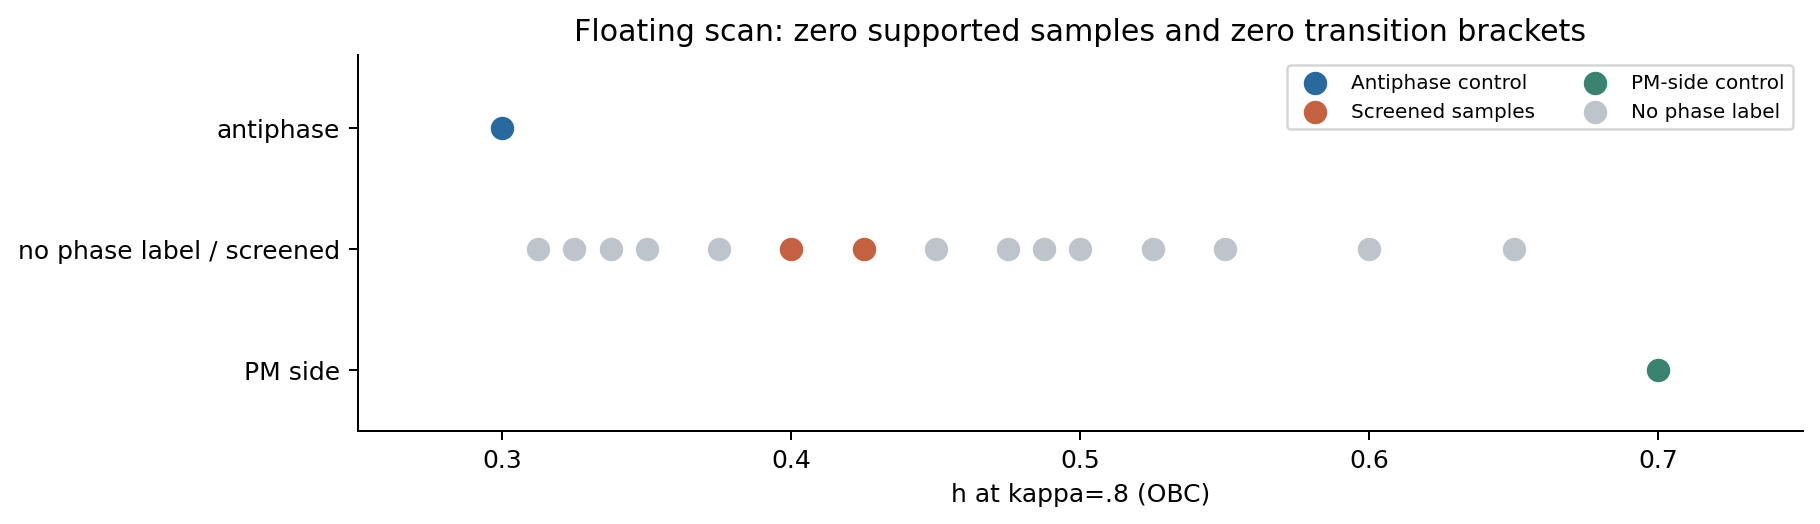

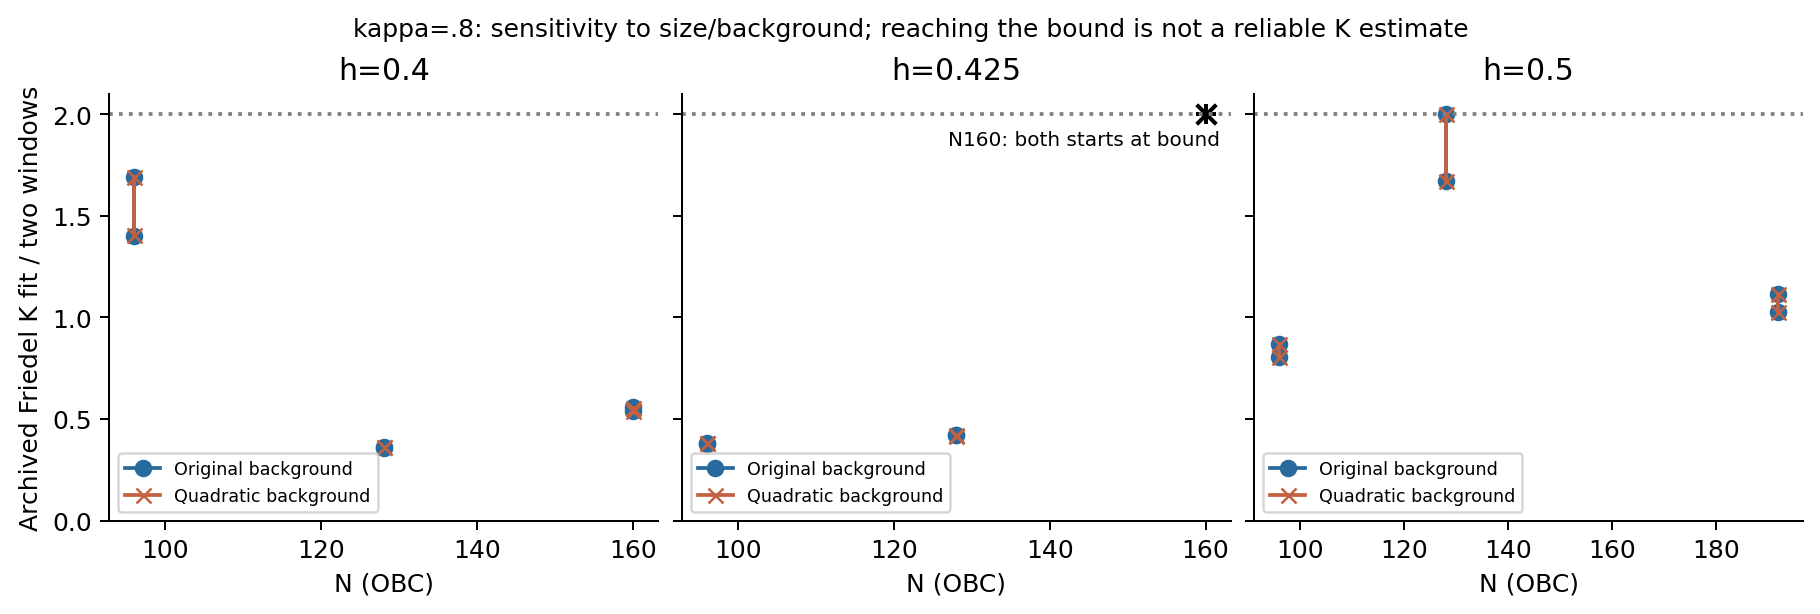

In [7]:
print(json.dumps(stats["extensions"], indent=2))
display(Image(filename=str(OUT / "extensions.png")))
display(Image(filename=str(OUT / "dynamics.png")))
display(Image(filename=str(OUT / "floating_evidence.png")))
display(Image(filename=str(OUT / "floating_fit_sensitivity.png")))

## Fresh lightweight validation
This cell compiles saved B3 parameters into gates, checks the saved state, evolves p=0 and p=.01 with a target-only channel, checks energy/SF identities and measurement probabilities. No ED state is loaded as the prepared circuit input. `--sdk` separately runs PennyLane in the scientific environment.

In [8]:
fresh = release.physics(OUT, sdk=False)
print(json.dumps(fresh, indent=2))
# One shared coordinate and equal-G budget for all estimators, all 32 repeats.
example_point = next(r["point_id"] for _, r in release.records() if r["method"]=="raw" and r["p"]==.01 and r["mode"]=="equal_gate" and r["budget"]==100000)
for method in ["raw", "zne_quadratic", "sv"]:
    record = next(r for _, r in release.records() if r["method"]==method and r["p"]==.01 and r["mode"]=="equal_gate" and r["budget"]==100000 and r["point_id"]==example_point)
    with np.load(release.path(record["archive"])) as arrays:
        rebuilt = release.samples_from_counts(record, arrays)
        np.testing.assert_allclose(rebuilt, arrays["samples"], atol=2e-12, rtol=2e-12)
    print(method, "reconstructed saved estimates:", rebuilt.shape, "G=", record["CNOT_shots_per_repeat"])

{
  "status": "PASS",
  "environment": {
    "python": "3.12.14",
    "python_build": "3.12.14 (main, Aug 25 2026, 13:50:33) [Clang 22.1.3 ]",
    "numpy": "2.3.5",
    "scipy": "1.17.0",
    "platform": "macOS-26.6.2-arm64-arm-64bit",
    "machine": "arm64",
    "bit_generator": "PCG64"
  },
  "point": [
    0.3,
    0.4125
  ],
  "parameters_to_gates": true,
  "cnots": 95,
  "target_counts": [
    0,
    11,
    11,
    7,
    9,
    15,
    21,
    21
  ],
  "p": [
    0,
    0.01
  ],
  "energy_p0": -6.156393727325989,
  "probability_max_error": 0.0,
  "atol": 2e-10,
  "SDK": "NOT_REQUESTED",
  "seconds": 2.481379124976229
}


raw reconstructed saved estimates: (32, 17) G= 12700000


zne_quadratic reconstructed saved estimates: (32, 17) G= 12700000


sv reconstructed saved estimates: (32, 17) G= 12700000


### Portable deterministic data checks (V1)
The separate deep V1 command verifies the manifest, all active joint-count estimates, integer resource equality, coordinates, gate tables and denominators. Default Run All uses the representative checks above, avoiding a full count audit. It does not resample historical RNG streams. V3 is optional and has an environment gate; a skip is not a pass.

In [9]:
print("Representative count and physical checks completed above.")
print("Deep V1: python scripts/release.py verify-data")

Representative count and physical checks completed above.
Deep V1: python scripts/release.py verify-data


## Reproduction and conclusion
From this directory: `python scripts/release.py redraw --out build/redraw`, `python scripts/release.py verify-data`, `python scripts/release.py verify-physics --quick --sdk`, and optional `python scripts/release.py verify-exact-replay`.

Explicit research entry (not run by this notebook): `python scripts/recompute.py --compute --kappa 0.3 --h 0.5 --out build/research`. It invokes the original bounded B3 implementation and writes new data separately. Full historical orchestration is retained in `research_scripts/` with its original provenance and expired run guards; do not mistake those scripts for a default quick start.

The submission establishes a preparation/resource/observable tradeoff and a real equal-CNOT-shots mitigation comparison. It also demonstrates why improved observable MSE is insufficient to certify boundaries. The results retain failed low-field preparations, branch changes, detector rejections and finite-size effects.

References: [Q-SITE task](https://github.com/benmcdonough20/QSITE-2026-QuantumCoalition), [qubit ADAPT](https://arxiv.org/abs/1911.10205), [ANNNI tensor-network study](https://arxiv.org/abs/2402.11022), [floating-phase DMRG](https://arxiv.org/abs/cond-mat/0702676), [symmetry verification](https://arxiv.org/abs/1807.10050). Published XX/Z conventions map to this ZZ/X convention by local Hadamards; OBC/PBC and finite-size evidence remain distinct. See `docs/KNOWN_LIMITATIONS.md`, `provenance/SOURCE_MAP.csv` and the immutable manifests.